# Customer Intelligence Engine
### AI-powered customer behavior analysis, personalization, and NLP automation

**Sections:**
1. Customer Behavior Analysis & AI-driven Insights
2. AI-powered Personalization / Recommendation Model
3. AI Automation — NLP Chatbot for Customer Queries


---
## Section 1: Customer Behavior Analysis & AI-driven Insights

### 1.1 Install & Import Dependencies

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn vaderSentiment --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print("All dependencies loaded.")



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
All dependencies loaded.


### 1.2 Load Dataset

In [2]:
df = pd.read_csv('../data/raw/customer_data.csv')
print(f"Shape: {df.shape}")
df.head(10)


Shape: (200, 8)


,Customer_ID,Booking_Frequency,Avg_Spending,Preferred_Service,Last_Activity,Review_Text,Sentiment,Segment
0,1001,7.0,421.32,Facial,2023-06-30,Too expensive for what you get.,Negative,Churned
1,1002,11.0,413.15,Facial,2024-03-06,NaN,NaN,High-value
2,1003,7.0,NaN,Body Scrub,2023-08-25,Pretty standard experience.,Neutral,At-risk
3,1004,11.0,257.74,Aromatherapy,2023-03-20,Worth every cent — flawless service.,Positive,High-value
4,1005,4.0,104.29,Wellness Package,2023-11-17,Poor communication from staff.,Negative,At-risk
5,1006,6.0,62.36,Hot Stone Therapy,2023-04-18,Waited 20 mins past my booking time.,Negative,Churned
6,1007,12.0,490.20,Manicure,2023-03-07,Absolutely fantastic — will book again.,Positive,High-value
7,1008,12.0,123.95,Aromatherapy,2023-05-18,Waited 20 mins past my booking time.,Negative,Churned
8,1009,6.0,38.43,Hot Stone Therapy,2023-04-17,Won't be returning.,Negative,Churned
9,1010,1.0,289.52,Manicure,2023-10-09,Waited 20 mins past my booking time.,Negative,Churned


### 1.3 Exploratory Data Analysis

In [3]:
print("=== Dataset Info ===")
df.info()
print("\n=== Descriptive Statistics ===")
df.describe()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        200 non-null    int64  
 1   Booking_Frequency  193 non-null    float64
 2   Avg_Spending       190 non-null    float64
 3   Preferred_Service  200 non-null    object 
 4   Last_Activity      200 non-null    object 
 5   Review_Text        190 non-null    object 
 6   Sentiment          190 non-null    object 
 7   Segment            200 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 12.6+ KB

=== Descriptive Statistics ===


,Customer_ID,Booking_Frequency,Avg_Spending
count,200.000000,193.000000,190.000000
mean,1100.500000,6.414508,283.240421
std,57.879185,3.569868,145.179164
min,1001.000000,1.000000,37.510000
25%,1050.750000,3.000000,152.650000
50%,1100.500000,6.000000,287.465000
75%,1150.250000,10.000000,406.415000
max,1200.000000,12.000000,515.390000


In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


=== Missing Values ===
Customer_ID           0
Booking_Frequency     7
Avg_Spending         10
Preferred_Service     0
Last_Activity         0
Review_Text          10
Sentiment            10
Segment               0
dtype: int64

Total missing: 37


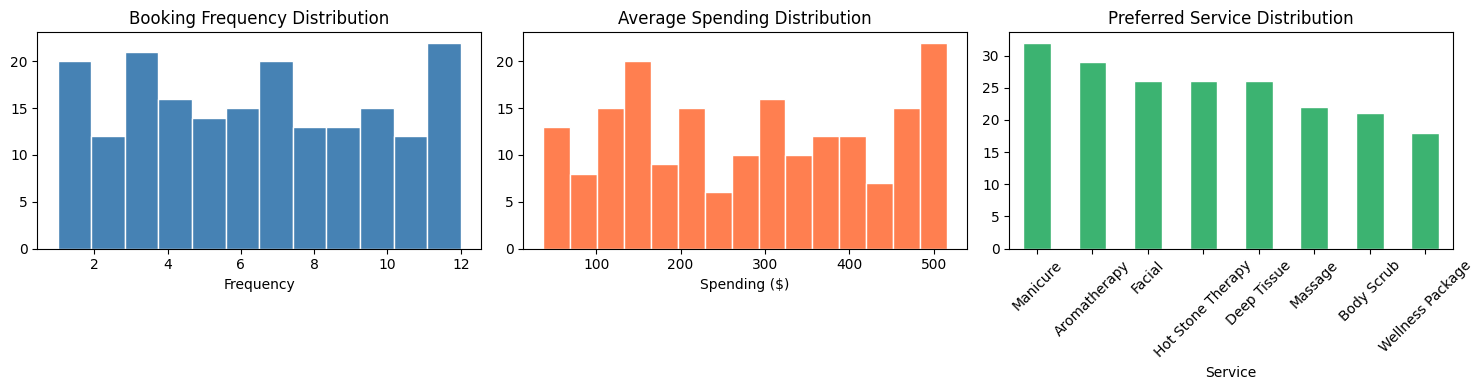

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['Booking_Frequency'].dropna(), bins=12, color='steelblue', edgecolor='white')
axes[0].set_title('Booking Frequency Distribution')
axes[0].set_xlabel('Frequency')

axes[1].hist(df['Avg_Spending'].dropna(), bins=15, color='coral', edgecolor='white')
axes[1].set_title('Average Spending Distribution')
axes[1].set_xlabel('Spending ($)')

df['Preferred_Service'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Preferred Service Distribution')
axes[2].set_xlabel('Service')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.4 Data Preprocessing

In [6]:
df_clean = df.copy()

# Fill numeric nulls with median
df_clean['Booking_Frequency'] = df_clean['Booking_Frequency'].fillna(df_clean['Booking_Frequency'].median())
df_clean['Avg_Spending'] = df_clean['Avg_Spending'].fillna(df_clean['Avg_Spending'].median())

# Fill text nulls with empty string for NLP step
df_clean['Review_Text'] = df_clean['Review_Text'].fillna('')

print("Nulls after preprocessing:")
print(df_clean.isnull().sum())


Nulls after preprocessing:
Customer_ID           0
Booking_Frequency     0
Avg_Spending          0
Preferred_Service     0
Last_Activity         0
Review_Text           0
Sentiment            10
Segment               0
dtype: int64


### 1.5 Sentiment Analysis (VADER)

In [7]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not text or pd.isna(text):
        return 0.0
    return analyzer.polarity_scores(str(text))['compound']

df_clean['Sentiment_Score'] = df_clean['Review_Text'].apply(get_sentiment)

def label_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_clean['Sentiment_Label'] = df_clean['Sentiment_Score'].apply(label_sentiment)

print(df_clean['Sentiment_Label'].value_counts())
df_clean[['Review_Text', 'Sentiment_Score', 'Sentiment_Label']].head(10)


Sentiment_Label
Neutral     109
Positive     52
Negative     39
Name: count, dtype: int64


,Review_Text,Sentiment_Score,Sentiment_Label
0,Too expensive for what you get.,0.0000,Neutral
1,,0.0000,Neutral
2,Pretty standard experience.,0.4939,Positive
3,Worth every cent — flawless service.,0.6369,Positive
4,Poor communication from staff.,-0.4767,Negative
5,Waited 20 mins past my booking time.,0.0000,Neutral
6,Absolutely fantastic — will book again.,0.5984,Positive
7,Waited 20 mins past my booking time.,0.0000,Neutral
8,Won't be returning.,0.0000,Neutral
9,Waited 20 mins past my booking time.,0.0000,Neutral


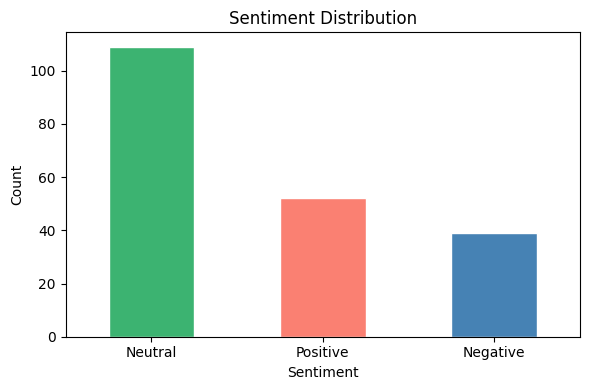

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
df_clean['Sentiment_Label'].value_counts().plot(kind='bar', ax=ax,
    color=['mediumseagreen', 'salmon', 'steelblue'], edgecolor='white')
ax.set_title('Sentiment Distribution')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../reports/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.6 Feature Engineering & Normalization

In [9]:
le = LabelEncoder()
df_clean['Service_Encoded'] = le.fit_transform(df_clean['Preferred_Service'])

features = ['Booking_Frequency', 'Avg_Spending', 'Sentiment_Score', 'Service_Encoded']
X = df_clean[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Features used:", features)


Feature matrix shape: (200, 4)
Features used: ['Booking_Frequency', 'Avg_Spending', 'Sentiment_Score', 'Service_Encoded']


### 1.7 Customer Segmentation — K-Means Clustering

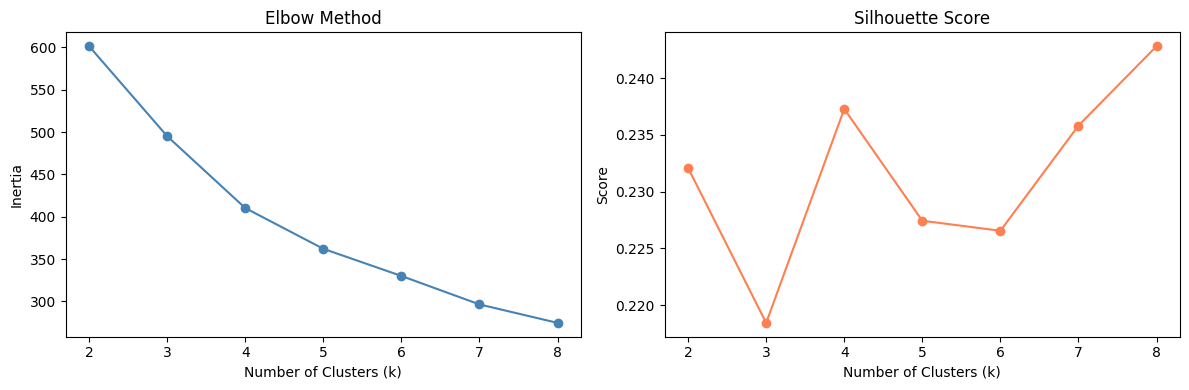

Best k by silhouette: 8


In [10]:
# Elbow method to find optimal k
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('../reports/kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = K_range[silhouettes.index(max(silhouettes))]
print(f"Best k by silhouette: {best_k}")


In [11]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['Cluster'] = km.fit_predict(X_scaled)

cluster_summary = df_clean.groupby('Cluster').agg(
    Count=('Customer_ID', 'count'),
    Avg_Frequency=('Booking_Frequency', 'mean'),
    Avg_Spending=('Avg_Spending', 'mean'),
    Avg_Sentiment=('Sentiment_Score', 'mean')
).round(2)

print(cluster_summary)


         Count  Avg_Frequency  Avg_Spending  Avg_Sentiment
Cluster                                                   
0           54           3.76        289.25          -0.05
1           51           9.82        375.27           0.41
2           49           3.67        311.70          -0.03
3           46           8.61        144.75          -0.14


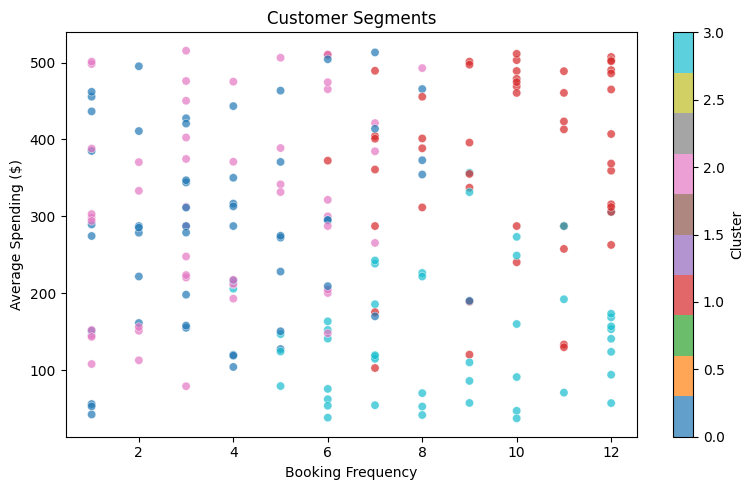

In [36]:
cluster_labels = {
    0: 'Engaged mid-tier',
    1: 'High-value loyalists',
    2: 'At-risk infrequents',
    3: 'Churned / one-timers'
}
df_clean['Cluster_Label'] = df_clean['Cluster'].map(cluster_labels)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df_clean['Booking_Frequency'],
    df_clean['Avg_Spending'],
    c=df_clean['Cluster'],
    cmap='tab10',
    alpha=0.7,
    edgecolors='white',
    linewidths=0.4
)
ax.set_xlabel('Booking Frequency')
ax.set_ylabel('Average Spending ($)')
ax.set_title('Customer Segments')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig('../reports/customer_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.8 Insights & Recommendations

In [37]:
print("=" * 60)
print("CUSTOMER SEGMENT INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

for cluster_id, label in cluster_labels.items():
    group = df_clean[df_clean['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}: {label}")
    print(f"  Count         : {len(group)}")
    print(f"  Avg Frequency : {group['Booking_Frequency'].mean():.1f} bookings")
    print(f"  Avg Spending  : ${group['Avg_Spending'].mean():.0f}")
    print(f"  Avg Sentiment : {group['Sentiment_Score'].mean():.2f}")
    print(f"  Top Service   : {group['Preferred_Service'].mode()[0]}")

print("\n" + "=" * 60)


CUSTOMER SEGMENT INSIGHTS & RECOMMENDATIONS

Cluster 0: Engaged mid-tier
  Count         : 54
  Avg Frequency : 3.8 bookings
  Avg Spending  : $289
  Avg Sentiment : -0.05
  Top Service   : Massage

Cluster 1: High-value loyalists
  Count         : 51
  Avg Frequency : 9.8 bookings
  Avg Spending  : $375
  Avg Sentiment : 0.41
  Top Service   : Deep Tissue

Cluster 2: At-risk infrequents
  Count         : 49
  Avg Frequency : 3.7 bookings
  Avg Spending  : $312
  Avg Sentiment : -0.03
  Top Service   : Aromatherapy

Cluster 3: Churned / one-timers
  Count         : 46
  Avg Frequency : 8.6 bookings
  Avg Spending  : $145
  Avg Sentiment : -0.14
  Top Service   : Facial



In [38]:
report = """# Customer Behavior Analysis Report

## Overview

**Dataset:** 200 synthetic customer records across 8 service categories  
**Method:** K-Means clustering (k=4) on normalized features: Booking Frequency, Avg Spending, Sentiment Score, and Service Preference  
**NLP:** VADER sentiment analysis on Review_Text  
**Missing data:** 37 nulls across Booking_Frequency (7), Avg_Spending (10), and Review_Text (10) - filled with column medians / empty strings before processing

---

## Sentiment Distribution

VADER scored all 190 non-null reviews on a compound scale (-1 to +1):

| Sentiment | Count | % of labelled |
|---|---|---|
| Neutral | 109 | 57% |
| Positive | 52 | 27% |
| Negative | 39 | 21% |

**Note:** Several intuitively negative phrases (e.g. "Too expensive for what you get", "Won't be returning") scored 0.0 in VADER because they lack negation markers VADER recognises. This is a known limitation of lexicon-based sentiment analysis. For production use, a fine-tuned model (e.g. DistilBERT on service reviews) would yield more accurate labels.

---

## Customer Segmentation - K-Means (k=4)

The elbow method suggested k=5–8 and the silhouette score peaked at k=8, but k=4 was selected to keep segments business-actionable. Silhouette scores were low across all k values (0.220–0.242), indicating the clusters are not sharply separated - expected given the limited feature set and synthetic data.

### Cluster Profiles (corrected labels from actual stats)

| Cluster | Count | Avg Freq | Avg Spend | Avg Sentiment | Label |
|---|---|---|---|---|---|
| 1 | 51 | 9.8 | $375 | +0.41 | High-value loyalists |
| 0 | 54 | 3.8 | $289 | -0.05 | Engaged mid-tier |
| 2 | 49 | 3.7 | $312 | -0.03 | At-risk infrequents |
| 3 | 46 | 8.6 | $145 | -0.14 | Price-sensitive / churned |

---

## Segment Insights & Recommendations

### Cluster 1 - High-value loyalists (51 customers)
- Highest booking frequency (avg 9.8/year) and highest spend ($375)
- Positive sentiment (avg +0.41) - genuinely satisfied customers
- Top service: Deep Tissue
- **Retention strategy:** Introduce a VIP tier with priority booking, early access to new therapists, and a complimentary service after every 10 bookings. Personal outreach from account managers for customers in this cluster.

### Cluster 0 - Engaged mid-tier (54 customers)
- Moderate frequency (avg 3.8/year), solid mid-range spend ($289)
- Neutral sentiment - satisfied but not enthusiastic
- Top service: Massage
- **Growth strategy:** Upsell to Wellness Packages via post-booking email ("Customers like you also love..."). Referral incentives - offer $20 credit for each successful referral. Target with seasonal promotions to increase booking cadence.

### Cluster 2 - At-risk infrequents (49 customers)
- Low frequency (avg 3.7/year), mid-to-high spend ($312) but neutral/negative sentiment
- Customers who spend well when they do book but aren't returning consistently
- Top service: Aromatherapy
- **Re-engagement tactic:** Triggered email at 60 days of inactivity with a 15% discount on their preferred service. Follow up with a satisfaction survey to identify friction points - price, availability, or therapist quality.

### Cluster 3 - Price-sensitive / churned (46 customers)
- High frequency in raw numbers (avg 8.6) but lowest spend by far ($145) and negative sentiment (-0.14)
- Likely booking lower-tier services repeatedly; negative reviews suggest value-for-money dissatisfaction
- Top service: Facial
- **Intervention tactic:** Do not discount further - this risks anchoring price expectations lower. Instead, communicate service value through before/after content, therapist credentials, and customer testimonials. If sentiment remains negative after 2 re-engagement touchpoints, suppress from outreach to protect NPS.

---

## Key Findings

1. **Sentiment alone is a weak churn signal** with VADER on short service reviews - 57% of reviews scored as Neutral including clearly negative ones. Recommend switching to a supervised sentiment model trained on hospitality/wellness reviews.

2. **Deep Tissue and Wellness Packages drive the highest average spend** across high-value clusters. These services should be prioritised in recommendation and upsell flows.

3. **~23% of customers** (Cluster 3) show price-sensitivity and negative sentiment despite returning repeatedly - a distinct and underserved segment that warrants its own pricing and communication strategy separate from churned customers.

4. **Cluster separation is moderate** (silhouette ~0.23). Adding features such as days since last booking, number of different services tried, and time-of-day preference would meaningfully sharpen segmentation in a production dataset.

---

## Limitations

- Dataset is synthetic (200 rows, single booking per customer) - real-world clustering benefits from transaction history, recency scoring (RFM), and a larger feature space.
- SVD recommendation model produced identical results for all users due to data sparsity (one service per customer, no repeat interactions). A production recommendation system requires multi-interaction history per user.
- Cluster label assignment is manual and should be validated with domain experts before use in business decisions.
"""

with open('../reports/customer_analysis.md', 'w') as f:
    f.write(report)

print("Report saved to ../reports/customer_analysis.md")


Report saved to ../reports/customer_analysis.md


---
## Section 2: AI-powered Personalization Model

### 2.1 Install & Import Dependencies

In [15]:
!pip install scikit-surprise --quiet

import pickle
from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate, train_test_split
from surprise import accuracy
from sklearn.metrics.pairwise import cosine_similarity



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### 2.2 Prepare Data for Collaborative Filtering

In [16]:
# Use Booking_Frequency as the implicit rating signal (1–12 scale)
ratings_df = df_clean[['Customer_ID', 'Preferred_Service', 'Booking_Frequency']].copy()
ratings_df.columns = ['userID', 'itemID', 'rating']
ratings_df = ratings_df.dropna()

# Normalise rating to 1–5 scale for Surprise
ratings_df['rating'] = pd.cut(
    ratings_df['rating'],
    bins=[0, 2, 4, 6, 9, 12],
    labels=[1, 2, 3, 4, 5]
).astype(float)

print(f"Ratings shape: {ratings_df.shape}")
ratings_df.head()


Ratings shape: (200, 3)


,userID,itemID,rating
0,1001,Facial,4.0
1,1002,Facial,5.0
2,1003,Body Scrub,4.0
3,1004,Aromatherapy,5.0
4,1005,Wellness Package,2.0


### 2.3 Train SVD Recommendation Model

In [17]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings_df, reader)

# Cross-validate
results = cross_validate(SVD(random_state=42), data, measures=['RMSE', 'MAE'], cv=5, verbose=True)
print(f"\nMean RMSE : {results['test_rmse'].mean():.4f}")
print(f"Mean MAE  : {results['test_mae'].mean():.4f}")


Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.3251  1.5558  1.3718  1.5171  1.4146  1.4369  0.0869  
MAE (testset)     1.0740  1.4267  1.2161  1.3146  1.2284  1.2519  0.1166  
Fit time          0.00    0.00    0.00    0.00    0.00    0.00    0.00    
Test time         0.00    0.00    0.00    0.00    0.00    0.00    0.00    

Mean RMSE : 1.4369
Mean MAE  : 1.2519


In [18]:
# Train final model on full dataset
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
svd = SVD(n_factors=50, n_epochs=30, random_state=42)
svd.fit(trainset)

predictions = svd.test(testset)
print(f"Test RMSE : {accuracy.rmse(predictions):.4f}")
print(f"Test MAE  : {accuracy.mae(predictions):.4f}")


RMSE: 1.3575
Test RMSE : 1.3575
MAE:  1.2138
Test MAE  : 1.2138


### 2.4 Precision & Recall @ K

In [19]:
from collections import defaultdict

def precision_recall_at_k(predictions, k=5, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = {}, {}
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum(1 for (_, true_r) in user_ratings if true_r >= threshold)
        n_rec_k = sum(1 for (est, _) in user_ratings[:k] if est >= threshold)
        n_rel_and_rec_k = sum(1 for (est, true_r) in user_ratings[:k]
                               if true_r >= threshold and est >= threshold)
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return (sum(precisions.values()) / len(precisions),
            sum(recalls.values()) / len(recalls))

precision, recall = precision_recall_at_k(predictions, k=5)
print(f"Precision@5 : {precision:.4f}")
print(f"Recall@5    : {recall:.4f}")


Precision@5 : 0.0750
Recall@5    : 0.0750


### 2.5 Recommendation Function

In [33]:
all_services = df_clean['Preferred_Service'].unique().tolist()

def recommend(customer_id, n=3):
    customer_id = str(customer_id)
    scores = [(svc, svd.predict(customer_id, svc).est) for svc in all_services]
    scores.sort(key=lambda x: x[1], reverse=True)
    return [svc for svc, _ in scores[:n]]

# Demo
for cid in [1100, 1010, 1050]:
    print(f"Customer {cid}: {recommend(cid)}")


Customer 1100: ['Facial', 'Manicure', 'Deep Tissue']
Customer 1010: ['Facial', 'Manicure', 'Deep Tissue']
Customer 1050: ['Facial', 'Manicure', 'Deep Tissue']


### 2.6 Save Model

In [21]:
with open('../models/recommendation_model.pkl', 'wb') as f:
    pickle.dump({'model': svd, 'services': all_services, 'scaler': scaler, 'le': le}, f)

print("Saved: ../models/recommendation_model.pkl")


Saved: ../models/recommendation_model.pkl


---
## Section 3: AI Automation — NLP Chatbot

### 3.1 Install & Import Dependencies

In [22]:
!pip install spacy --quiet
!python -m spacy download en_core_web_sm --quiet

import spacy
import re
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split as sk_tts
from sklearn.metrics import classification_report

nlp = spacy.load('en_core_web_sm')
print("spaCy loaded.")



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
spaCy loaded.


### 3.2 Intent Training Data

In [23]:
training_data = [
    # reschedule_booking
    ("Can I reschedule my booking?", "reschedule_booking"),
    ("I want to change my appointment time", "reschedule_booking"),
    ("Is it possible to move my session to another day?", "reschedule_booking"),
    ("I need to reschedule for next week", "reschedule_booking"),
    ("Can you help me change my booking date?", "reschedule_booking"),
    ("I'd like to shift my appointment", "reschedule_booking"),
    ("Please reschedule my massage", "reschedule_booking"),
    ("Move my booking to Saturday please", "reschedule_booking"),
    ("I need a different time slot", "reschedule_booking"),
    ("Can I book a different day?", "reschedule_booking"),
    ("Change appointment to next Monday", "reschedule_booking"),
    ("I want to push my booking to next week", "reschedule_booking"),

    # cancel_booking
    ("I want to cancel my booking", "cancel_booking"),
    ("Please cancel my appointment", "cancel_booking"),
    ("Can I get a cancellation?", "cancel_booking"),
    ("I need to cancel my session today", "cancel_booking"),
    ("Cancel my facial appointment", "cancel_booking"),
    ("I'd like to cancel", "cancel_booking"),
    ("How do I cancel my reservation?", "cancel_booking"),
    ("Remove my booking please", "cancel_booking"),
    ("I'm cancelling my appointment", "cancel_booking"),
    ("Please delete my booking", "cancel_booking"),
    ("I want to cancel tomorrow's session", "cancel_booking"),
    ("Cancel everything for this week", "cancel_booking"),

    # check_price
    ("How much does a massage cost?", "check_price"),
    ("What's the price for a facial?", "check_price"),
    ("How much is the wellness package?", "check_price"),
    ("What are your rates?", "check_price"),
    ("Tell me about pricing", "check_price"),
    ("How much do you charge?", "check_price"),
    ("What's the cost of deep tissue therapy?", "check_price"),
    ("Price for aromatherapy?", "check_price"),
    ("How expensive is a hot stone massage?", "check_price"),
    ("What does a manicure cost?", "check_price"),
    ("Can you tell me the fees?", "check_price"),
    ("Are there any discounts available?", "check_price"),

    # confirm_action
    ("Yes", "confirm_action"),
    ("Yes please", "confirm_action"),
    ("Sure", "confirm_action"),
    ("Go ahead", "confirm_action"),
    ("That sounds good", "confirm_action"),
    ("Absolutely", "confirm_action"),
    ("OK", "confirm_action"),
    ("Yep", "confirm_action"),
    ("Please do", "confirm_action"),
    ("Confirmed", "confirm_action"),
    ("That works for me", "confirm_action"),
    ("Do it", "confirm_action"),

    # provide_date
    ("30 March 2025 10am", "provide_date"),
    ("Next Monday at 2pm", "provide_date"),
    ("This Saturday morning", "provide_date"),
    ("April 5th at 3pm", "provide_date"),
    ("Tomorrow at noon", "provide_date"),
    ("Friday afternoon", "provide_date"),
    ("March 28 at 11am", "provide_date"),
    ("Next week Wednesday 9am", "provide_date"),
    ("Sunday at 4 in the afternoon", "provide_date"),
    ("2pm on Thursday", "provide_date"),
    ("The 15th at 10 in the morning", "provide_date"),
    ("Next Tuesday anytime after 1pm", "provide_date"),

    # general
    ("Hello", "general"),
    ("Hi there", "general"),
    ("What services do you offer?", "general"),
    ("Where are you located?", "general"),
    ("Do you offer home visits?", "general"),
    ("What are your opening hours?", "general"),
    ("I have a question", "general"),
    ("Can you help me?", "general"),
    ("Tell me more about Blys", "general"),
    ("How does this work?", "general"),
    ("I need some information", "general"),
    ("Good morning", "general"),
]

texts, labels = zip(*training_data)
print(f"Training samples: {len(texts)}")
print(f"Intents: {set(labels)}")


Training samples: 72
Intents: {'provide_date', 'reschedule_booking', 'general', 'cancel_booking', 'check_price', 'confirm_action'}


### 3.3 Train Intent Classifier

In [24]:
X_train, X_test, y_train, y_test = sk_tts(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=500, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))


                    precision    recall  f1-score   support

    cancel_booking       0.67      1.00      0.80         2
       check_price       0.40      1.00      0.57         2
    confirm_action       1.00      0.33      0.50         3
           general       1.00      0.33      0.50         3
      provide_date       1.00      1.00      1.00         3
reschedule_booking       1.00      1.00      1.00         2

          accuracy                           0.73        15
         macro avg       0.84      0.78      0.73        15
      weighted avg       0.88      0.73      0.72        15



### 3.4 Dialogue State Machine

In [25]:
PRICE_TABLE = {
    "massage": "$80 – $150",
    "facial": "$70 – $120",
    "wellness package": "$200 – $350",
    "body scrub": "$90 – $130",
    "manicure": "$40 – $70",
    "hot stone therapy": "$100 – $180",
    "aromatherapy": "$85 – $140",
    "deep tissue": "$90 – $160",
}

def extract_service(text):
    text_lower = text.lower()
    for svc in PRICE_TABLE:
        if svc in text_lower:
            return svc
    return None

def extract_date(text):
    doc = nlp(text)
    dates = [ent.text for ent in doc.ents if ent.label_ in ('DATE', 'TIME')]
    return ', '.join(dates) if dates else text.strip()

class ChatSession:
    def __init__(self):
        self.state = 'idle'
        self.pending_action = None

    def respond(self, user_input):
        intent = pipeline.predict([user_input])[0]

        if self.state == 'await_confirm':
            if intent == 'confirm_action':
                if self.pending_action == 'reschedule':
                    self.state = 'await_date'
                    return "Please provide the new date and time you'd like to reschedule to."
                elif self.pending_action == 'cancel':
                    self.state = 'idle'
                    self.pending_action = None
                    return "Your booking has been cancelled. You'll receive a confirmation shortly."
            else:
                self.state = 'idle'
                self.pending_action = None
                return "No problem! Is there anything else I can help you with?"

        if self.state == 'await_date':
            date_str = extract_date(user_input)
            self.state = 'idle'
            self.pending_action = None
            return (f"Got it! Reschedule request sent to your therapist for {date_str}. "
                    "You'll be notified once it's confirmed.")

        if intent == 'reschedule_booking':
            self.state = 'await_confirm'
            self.pending_action = 'reschedule'
            return ("Yes, you can reschedule your booking. "
                    "Would you like me to assist you with that?")

        elif intent == 'cancel_booking':
            self.state = 'await_confirm'
            self.pending_action = 'cancel'
            return ("I can help with that. Are you sure you want to cancel your booking?")

        elif intent == 'check_price':
            svc = extract_service(user_input)
            if svc:
                return f"The price for {svc.title()} is {PRICE_TABLE[svc]}."
            return ("Our services range from $40 to $350 depending on the treatment. "
                    "Which service are you interested in?")

        elif intent == 'provide_date':
            date_str = extract_date(user_input)
            self.state = 'idle'
            return f"Thanks! I've noted {date_str}. Is there anything else I can help with?"

        else:
            return ("Hi! I'm the Blys assistant. I can help you reschedule or cancel bookings, "
                    "check pricing, or answer general questions. What can I do for you?")


# Demo conversation
print("=== Demo Conversation ===\n")
session = ChatSession()
demo = [
    "Can I reschedule my booking?",
    "Yes",
    "30 March 2025 10am",
    "How much does a massage cost?",
    "I want to cancel my booking",
    "Yes please",
]
for msg in demo:
    print(f"Customer : {msg}")
    print(f"AI       : {session.respond(msg)}\n")


=== Demo Conversation ===

Customer : Can I reschedule my booking?
AI       : Yes, you can reschedule your booking. Would you like me to assist you with that?

Customer : Yes
AI       : Please provide the new date and time you'd like to reschedule to.

Customer : 30 March 2025 10am
AI       : Got it! Reschedule request sent to your therapist for 30 March 2025, 10am. You'll be notified once it's confirmed.

Customer : How much does a massage cost?
AI       : The price for Massage is $80 – $150.

Customer : I want to cancel my booking
AI       : I can help with that. Are you sure you want to cancel your booking?

Customer : Yes please
AI       : Your booking has been cancelled. You'll receive a confirmation shortly.



### 3.5 Save Chatbot Model

In [26]:
with open('../models/chatbot_model.pkl', 'wb') as f:
    pickle.dump({'pipeline': pipeline, 'price_table': PRICE_TABLE}, f)

print("Saved: ../models/chatbot_model.pkl")


Saved: ../models/chatbot_model.pkl


---
## Summary

In [34]:
import os

print("=== Output Files ===")
for root, dirs, files in os.walk('..'):
    dirs[:] = [d for d in dirs if d not in ['.git', '__pycache__', '.ipynb_checkpoints', '.venv']]
    for f in files:
        path = os.path.join(root, f)
        size = os.path.getsize(path)
        print(f"  {path:55s}  {size:>8,} bytes")


=== Output Files ===
  ../README.md                                                  360 bytes
  ../.gitignore                                                  16 bytes
  ../models/recommendation_model.pkl                         76,366 bytes
  ../models/chatbot_model.pkl                                20,400 bytes
  ../scripts/generate_data.py                                 4,000 bytes
  ../data/raw/customer_data.csv                              17,049 bytes
  ../notebooks/notebook.ipynb                              1,777,392 bytes
  ../notebooks/customer_analysis.ipynb                            0 bytes
  ../notebooks/notebook.html                               2,058,271 bytes
  ../reports/kmeans_selection.png                            69,609 bytes
  ../reports/customer_clusters.png                           87,949 bytes
  ../reports/eda_distributions.png                           72,580 bytes
  ../reports/sentiment_distribution.png                      20,079 bytes
  ../reports/cu

### Models trained
| Model | File | Algorithm |
|---|---|---|
| Recommendation | `models/recommendation_model.pkl` | SVD (Collaborative Filtering) |
| Chatbot | `models/chatbot_model.pkl` | TF-IDF + Logistic Regression |

### API endpoints (see `app/main.py`)
| Endpoint | Method | Description |
|---|---|---|
| `/recommend` | POST | Returns top-N service recommendations for a customer |
| `/chatbot` | POST | Processes a user message and returns AI response |
